# 1. **Project Title -  Flight Price Prediction**
### **Project Description** :
- In this project, we aim to build machine learning models that can accurately predict flight prices based on various features of dataset . By analyzing these factors, we aim to gain insights into what influences flight prices the most.

## 2. Project Team Id , Project Id and Deadlines

- **Project Team ID** : PTID-AIE-MAY-26-11218
- **Project ID** : PRCP-1025-FlightPricePrediction
- **Institute** : DataMites

## **3.Problem Statements and Goals**

### 3.1 Problem Statements :
**Task 1** :
- Prepare a complete data analysis report on the given data.

**Task 2** :
- **a)** Create a robust machine learning algorithm to accurately predict the price of the flight given the various factors across the market.      
- **b)** Determine the relationship between the flight features and how the price varies based on this.

### 3.2 Goals :

- I worked on building and training several machine learning regression models with the goal of accurately predicting flight prices.

- During the process, I focused on identifying the most important features that have a significant impact on pricing trends.

- I evaluated model’s performance using metrics such as RMSE and R² score to understand how well they captured the underlying patterns in the data.

- After careful comparison, I selected the best-performing model and saved it so it can be used later to make predictions on new, unseen data.

- Finally, I drew meaningful insights from the analysis, which can assist both customers and businesses in making smarter flight price decisions.

## 4. Dataset Source And Description :

- **Source** : Institute
- **Rows** : 10683
- **Columns** : 10
- **Traget Variable** : Price
- **Features** : Mixture of numerical and Categorical Variable
- **Description** : We have to analyze the flight fare prediction using Machine Learning dataset using essential exploratory data analysis techniques then will draw some predictions about the price of the flight based on some features such as what type of airline it is, what is the arrival time, what is the departure time, what is the duration of the flight, source, destination and more.

## **Notebook Roadmap** :

1. **Project Title and Description**
2. **Project Team Id , Project Id and Deadlines**
3. **Business Case**
    - 3.1 Problem Statements
    - 3.2 Goals
4. **Dataset souce and Description**
5. **Imports and Configurations**
6. **Dataset Loading**
7. **Domain Analysis**
8. **Basic checks/ initial inspection**
9. **Exploratory Data Analysis(EDA)**
   - 9.1 Univariate Analysis
   - 9.2 Bivariate Analysis
   - 9.3 Multivariate Analysis
10. **Feature Engineering**
    - 10.1 Data Preprocessing
        - 10.1.1 Checking for duplicate rows
        - 10.1.2 Null Value Handling
        - 10.1.3 Outlier handling
        - 10.1.4 Encoding
    - 10.2 Feature Selection
11. **Modeling**
    - 11.1 Spliting the data
    - 11.2 Train Test Split
    - 11.3 Model building , validating and Evaluation with and without hyperparameter tuning
        - 11.3.1 Linear Regression
        - 11.3.2 Ridge Regression
        - 11.3.3 Lasso Regression
        - 11.3.4 Random Forest Regressor
        - 11.3.5 Gradient Boosting Regressor
        - 11.3.6 XGBoost Regressor
    - 11.4 Best Model Based On R2 Score, MAE , RMSE etc.
12. **HyperParameter Tuning**
    - 12.1 Random Forest
    - 12.2 XGBoost

## 5. Imports and Configurations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from yreport import data_health_report
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
!pip install xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')

## 6. DataSet Loading :

In [2]:
!pip install openpyxl
df = pd.read_excel('/content/Flight_Fare.xlsx')
pd.set_option('display.max_rows', None)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 8.4 MB/s eta 0:00:00


In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


## 7. Domain Analysis :

-Dataset Overview :
-This is an Airline / Flight Fare Prediction dataset designed for predicting flight ticket prices based on airline, route, travel timing, duration, and number of stops.

-Here is the explanation of features of this dataset:-
1. **Airline** :
- Airline represents the name of the airline company providing the flight service.
- It has categorical values like:
IndiGo
Air India
Jet Airways
SpiceJet
Vistara
GoAir
- Impact on price is HIGH because different airlines have different pricing strategies, services, and brand value.
2. **Date_of_Journey** :
- Date_of_Journey represents the date when the passenger travels.
- It contains date values in format like:
24/03/2019
01/05/2019
- It can be converted into:
Journey Day
Journey Month
- Impact on price is MEDIUM because ticket prices change based on seasons, holidays, and travel demand.
3. **Source**:
- Source represents the departure city of the flight.
- It has categorical values like:
Banglore
Delhi
Kolkata
Mumbai
Chennai
- Impact on price is HIGH because different departure locations have different demand and flight availability.
4. **Destination** :
- Destination represents the arrival city of the flight.
- It has categorical values like:
Delhi
Cochin
New Delhi
Banglore
Hyderabad
- Impact on price is HIGH because popular destinations usually have higher demand and different fare ranges.
5. **Route** :
- Route represents the complete path taken by the flight.
- Example:
Delhi → Mumbai
Banglore → New Delhi
- It contains multiple route combinations.
- Impact on price is VERY HIGH because route distance, popularity, and availability directly affect ticket prices.
6. **Dep_Time** :
- Dep_Time represents the departure time of the flight.
- Example:
10:30
18:25
- It can be converted into:
Departure Hour
Departure Minute
- Impact on price is MEDIUM because morning/evening flights may have different demand.
7. **Arrival_Time** :
- Arrival_Time represents the arrival time of the flight.
- Example:
01:10
21:05
- It can be converted into:
Arrival Hour
Arrival Minute
- Impact on price is MEDIUM because convenient arrival timings may have higher demand.
8. **Duration** :
- Duration represents the total travel time of the flight.
- Example:
2h 50m
10h 15m
- It can be converted into total minutes.
- Impact on price is HIGH because longer flights usually have higher operational costs and different pricing.
9. **Total_Stops** :
- Total_Stops represents the number of stops between source and destination.
- It contains values like:
non-stop
1 stop
2 stops
3 stops
4 stops
- Impact on price is VERY HIGH because direct flights are usually more expensive than flights with multiple stops.
10. **Additional_Info** :
- Additional_Info represents extra details related to flight booking.
- Values include:
No info
In-flight meal not included
No check-in baggage
Business class
- Impact on price is LOW-MEDIUM because some additional services may affect ticket pricing.
### Target Column
11. **Price** :
- Price is the final flight ticket fare.
- It is the target variable that we want to predict.
- It contains continuous numerical values.

## 8. Basic check / Initial inspection :

In [5]:
df.shape

(10683, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [7]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [8]:
df.describe(include='O')

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683
unique,12,44,5,6,128,222,1343,368,5,10
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info
freq,3849,504,4537,4537,2376,233,423,550,5625,8345


In [9]:
df.sample(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
3906,Air India,12/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,12:00,19:15,7h 15m,2 stops,No info,8603
3563,Air India,24/06/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 25 Jun,21h 15m,2 stops,No info,9181
8508,IndiGo,6/03/2019,Delhi,Cochin,DEL → HYD → COK,08:35,16:10,7h 35m,1 stop,No info,7514
311,Jet Airways,3/06/2019,Delhi,Cochin,DEL → BOM → COK,16:00,19:00 04 Jun,27h,1 stop,No info,14714
1907,Air India,15/05/2019,Delhi,Cochin,DEL → BOM → COK,13:00,19:15,6h 15m,1 stop,No info,8372
7363,Vistara,12/05/2019,Banglore,Delhi,BLR → DEL,09:45,12:35,2h 50m,non-stop,No info,4668
5364,Air Asia,3/06/2019,Delhi,Cochin,DEL → BLR → COK,16:45,06:35 04 Jun,13h 50m,1 stop,No info,11410
240,Jet Airways,18/03/2019,Banglore,New Delhi,BLR → BOM → DEL,11:40,20:20,8h 40m,1 stop,No info,13555
8105,Jet Airways,27/05/2019,Delhi,Cochin,DEL → AMD → BOM → COK,19:10,19:00 28 May,23h 50m,2 stops,No info,15129
1581,IndiGo,3/06/2019,Delhi,Cochin,DEL → BOM → COK,07:30,21:00,13h 30m,1 stop,No info,6093


In [10]:
#data1 = data_health_report(df)
#data1.summary()

In [11]:
unique_counts = df.nunique().sort_values(ascending=True)
unique_counts

,0
Source,5
Total_Stops,5
Destination,6
Additional_Info,10
Airline,12
Date_of_Journey,44
Route,128
Dep_Time,222
Duration,368
Arrival_Time,1343


In [85]:
#for i in df.columns:
#  print('-' * 50)
#  print(i)
#  print(df[i].value_counts())

In [13]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


## 9. Exploratory Data Analysis(EDA)

In [14]:
# Converting Date_of_Journey into Journey_day, Journey_month, Journey_year
df['Journey_day'] = pd.to_datetime(df.Date_of_Journey, format = '%d/%m/%Y').dt.day
df['Journey_month'] = pd.to_datetime(df.Date_of_Journey, format='%d/%m/%Y').dt.month
df['Journey_Year'] = pd.to_datetime(df.Date_of_Journey, format='%d/%m/%Y').dt.year

In [15]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [16]:
df.Journey_Year.value_counts()

,count
Journey_Year,
2019,10683


In [17]:
# Since we have converted Date_of_Journey column into integers & there is we have oly 2019 data, Now we can drop as it is of no use.
df.drop(['Date_of_Journey','Journey_Year'],axis=1,inplace=True)

In [18]:
# Departure time is when a plane leaves the gate.
# Similar to Date_of_Journey we can extract values from Dep_Time
# Extracting Hours
df['Dep_hour'] = pd.to_datetime(df.Dep_Time).dt.hour
# Extracting Minutes
df['Dep_mins'] = pd.to_datetime(df.Dep_Time).dt.minute
# Now we can drop the Dep_time
df.drop(['Dep_Time'],axis=1,inplace=True)

In [19]:
# Extract Hour and Minute from Arrival_Time
df['Arrival_Hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_Min'] = pd.to_datetime(df['Arrival_Time']).dt.minute
# Now we can drop the Arrival time
df.drop('Arrival_Time', axis=1, inplace=True)

In [20]:
# Creating a fuction to covert a duration into total minutes
def convert_duration(duration):
    # Handle missing or null values correctly
    if pd.isna(duration):
        return None

    duration = str(duration).strip()
    hours = 0
    minutes = 0

    # Extract hours safely
    if 'h' in duration:
        hours_part = duration.split('h')[0].strip()
        if hours_part.isdigit():
            hours = int(hours_part)

    # Extract minutes safely
    if 'm' in duration:
        # Split by 'm' to get everything before it
        min_part = duration.split('m')[0]
        # If 'h' is also present, isolate the minutes after the 'h'
        if 'h' in min_part:
            min_part = min_part.split('h')[-1]

        min_part = min_part.strip()
        if min_part.isdigit():
            minutes = int(min_part)

    return hours * 60 + minutes

df['Duration_Mins'] = df['Duration'].apply(convert_duration)
df.drop('Duration', axis=1, inplace=True)
df['Duration_Mins'].describe()

,Duration_Mins
count,10683.000000
mean,643.093232
std,507.862001
min,5.000000
25%,170.000000
50%,520.000000
75%,930.000000
max,2860.000000


In [21]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_mins,Arrival_Hour,Arrival_Min,Duration_Mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,285


In [22]:
# Categorising columns intl Numerical & Categorical
num_cols = df.select_dtypes(include=['int64','int32','float64']).columns.drop(['Price','Duration_Mins'])
cat_cols = df.select_dtypes(include=['object']).columns
print('Numarical Columns :' ,list(num_cols))
print('Categorical columns :', list(cat_cols))

Numarical Columns : ['Journey_day', 'Journey_month', 'Dep_hour', 'Dep_mins', 'Arrival_Hour', 'Arrival_Min']
Categorical columns : ['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']


#### 9.1.Univariate Analysis

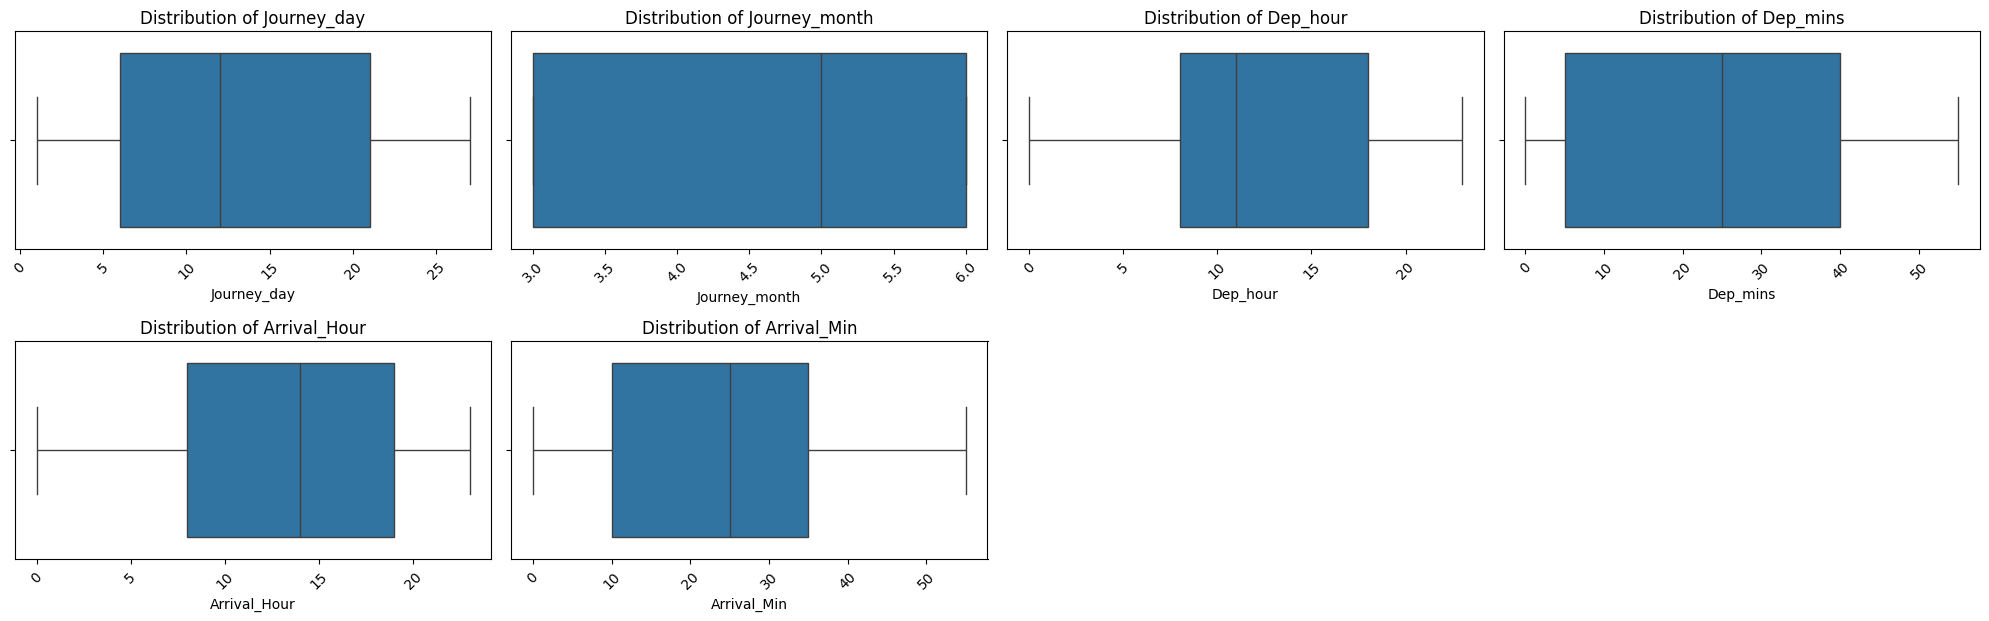

In [23]:
plt.figure(figsize=(20,12))
for i,col in enumerate(num_cols,1):
    plt.subplot(4,4,i)
    sns.boxplot(x=df[col],orient='h')
    plt.title(f'Distribution of {col}',fontsize=12)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Boxplots — Numerical ColumnsJourney_Day
- 1.Journey_Day : Bookings are spread pretty evenly across all days of the month. Nothing really stands out here — day of the month doesn't seem to influence much on its own.
  
- 2.Journey_Month : This one tells a clear story. March through June sees the heaviest traffic, people travelling for summer holidays and school breaks. Things quiet down in February and September when there's not much reason to travel.

- 3.Dep_Hour : Mornings are busy. Most flights take off between 6 and 10 AM, with another rush in the evening around 5 to 8 PM. The dead zone is clearly between 1 and 4 in the morning, almost nobody flies then.

- 4.Dep_Min : Airlines schedule departures at clean intervals - 00, 15, 30, 45. It's more about how airlines operate than any real pattern in the data.

- 5.Arrival_Hour : Arrivals are more spread out but tend to pile up in the evening. Late night arrivals between 10 PM and midnight are also fairly common mostly because of longer connecting flights.

- 6.Arrival_Min : Same story as departure minutes. Standard scheduling intervals, nothing analytically significant.

- 7.Duration_Mins : Most flights wrap up within 100 to 400 minutes, roughly 1.5 to 6.5 hours. There are a handful of very long flights that skew the distribution to the right. Those extreme values at the top are worth capping before modeling.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Source           10683 non-null  object
 2   Destination      10683 non-null  object
 3   Route            10682 non-null  object
 4   Total_Stops      10682 non-null  object
 5   Additional_Info  10683 non-null  object
 6   Price            10683 non-null  int64 
 7   Journey_day      10683 non-null  int32 
 8   Journey_month    10683 non-null  int32 
 9   Dep_hour         10683 non-null  int32 
 10  Dep_mins         10683 non-null  int32 
 11  Arrival_Hour     10683 non-null  int32 
 12  Arrival_Min      10683 non-null  int32 
 13  Duration_Mins    10683 non-null  int64 
dtypes: int32(6), int64(2), object(6)
memory usage: 918.2+ KB


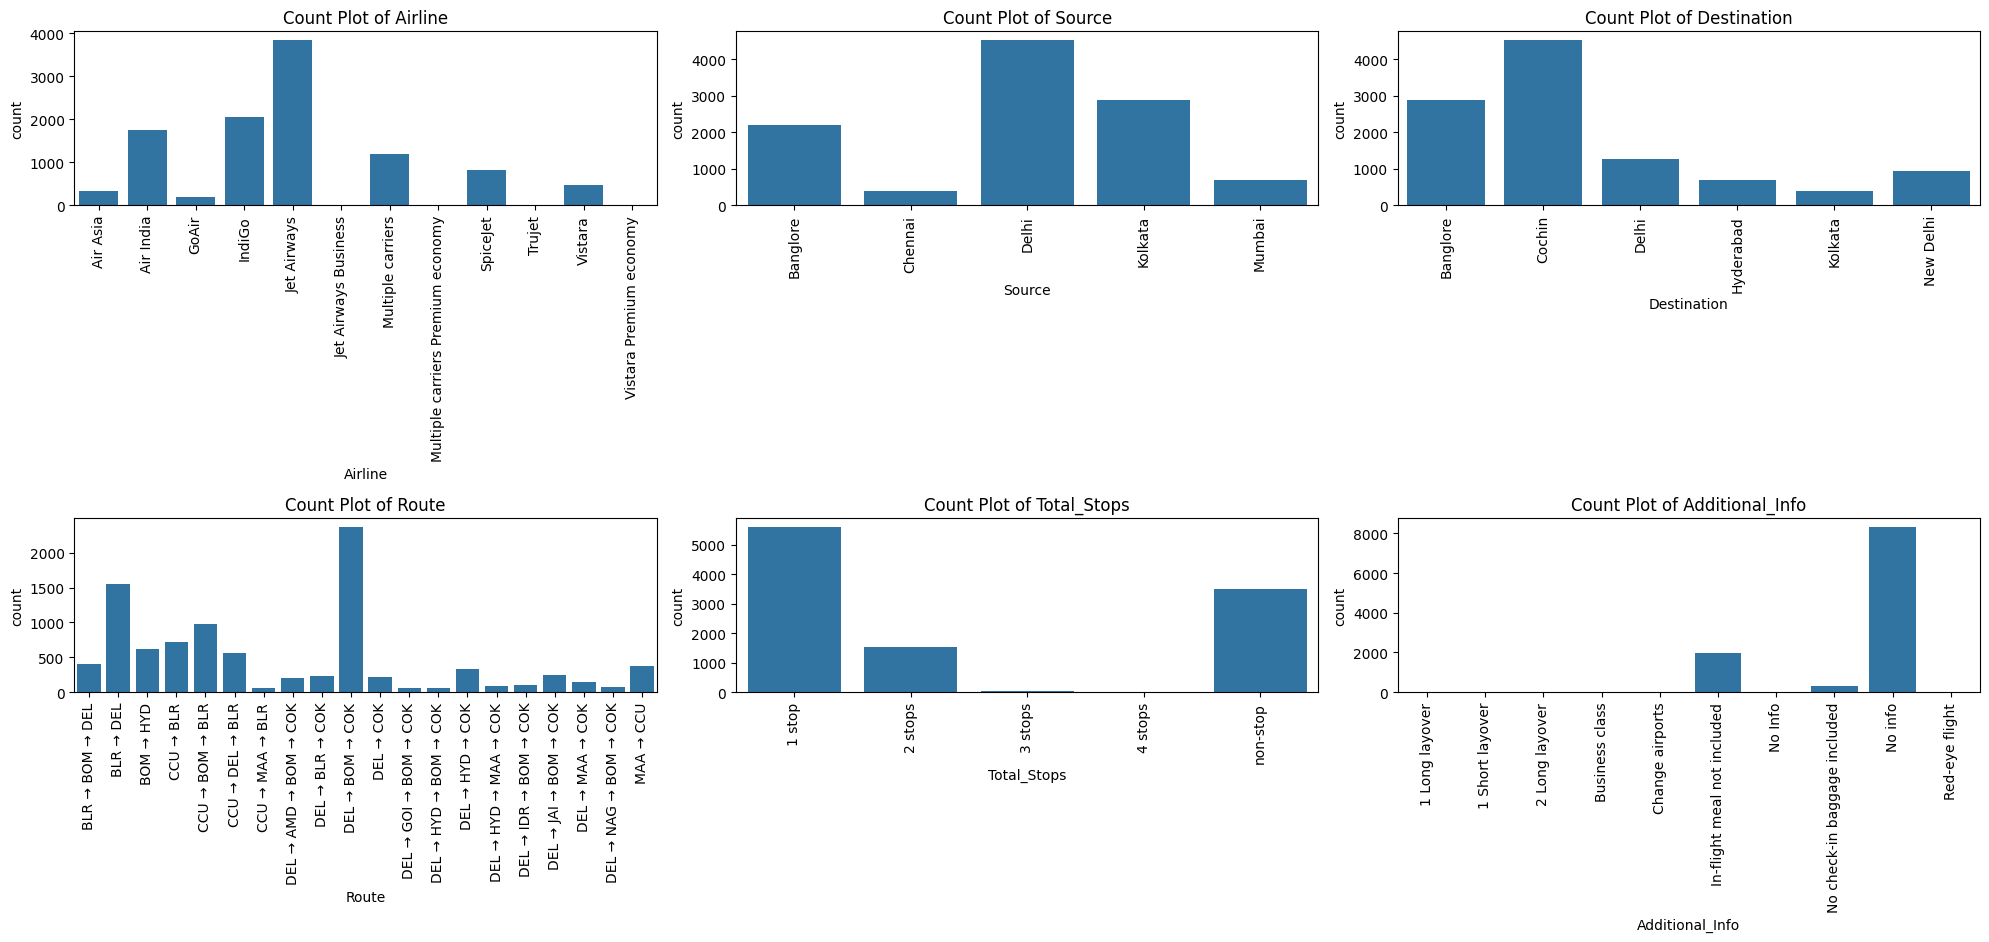

In [25]:
plt.figure(figsize=(20,12))
for i,col in enumerate(cat_cols,1):
    plt.subplot(3,3,i)
    top_categories = df[col].value_counts().index[:20].sort_values(ascending=True)
    sns.countplot(x=col,data=df,order=top_categories)
    plt.title(f"Count Plot of {col}",fontsize=12)
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Countplots — Categorical Columns
- Airline : Jet Airways dominates the dataset it's clearly the most popular carrier in terms of volume. Air India and Indigo are next. On the other end, Jet Airways Business and Vistara Premium Economy barely show up, they're niche premium options and it shows in the data.

- Source : Delhi and Bangalore are where most journeys begin. Chennai and Kolkata are quieter departure points. Mumbai falls somewhere in between.

- Destination : Cochin gets the most arrivals, followed by Bangalore and Delhi. One thing worth noting New Delhi and Delhi appear as separate entries in the data, which needs to be handled carefully during encoding.

- Total_Stops : Most people fly with one stop direct flights are less common than you'd think. Three and four stop journeys are rare enough that they don't tell us much statistically.

- Additional_Info : Over 80% of entries just say "No info." This column was never going to add much to the model dropping it will be the right call.

- Route : Hundreds of unique combinations here. DEL to BOM and BLR to DEL come up most often, but with so many unique routes it's not something we can encode cleanly which is why it was dropped.

#### 9.2.Bivariate Analysis

<Figure size 2000x1200 with 0 Axes>

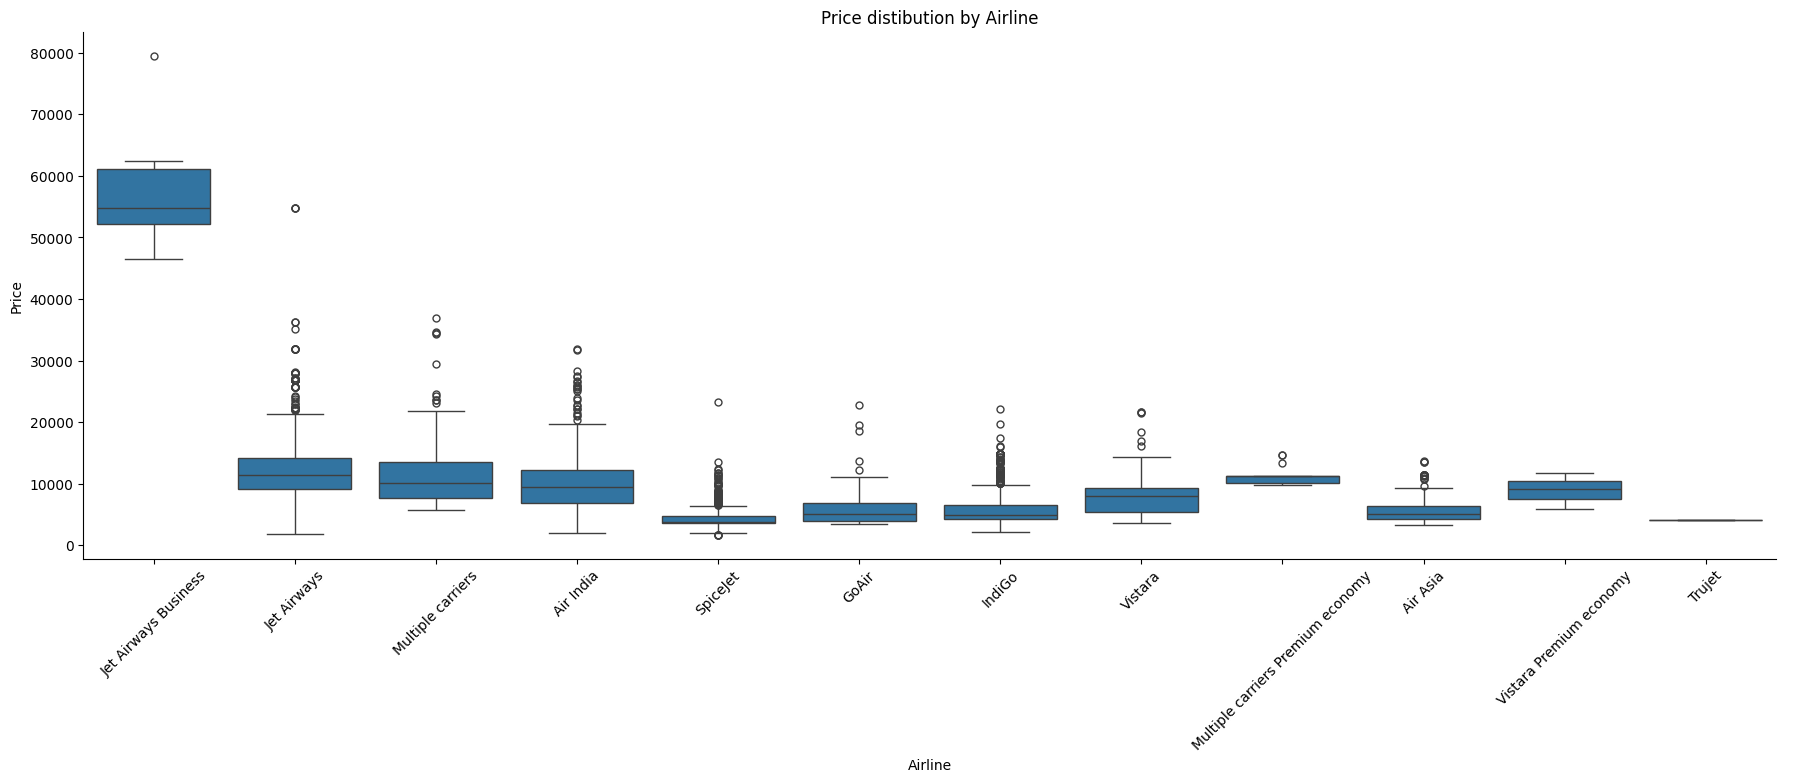

In [26]:
plt.figure(figsize=(20,12))
sns.catplot(x='Airline',y='Price',data=df.sort_values('Price',ascending=False),kind='box',height=6,aspect=3)
plt.title('Price distibution by Airline',fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Price vs Airline
- Jet Airways Business sits at the top by a wide margin, business class pricing is just a different league. Vistara Premium Economy and Multiple Carriers Premium Economy also command high prices. At the other end, IndiGo, SpiceJet, and GoAir are clearly budget-focused.
-  Air India lands in the middle, full service but economy pricing. One interesting thing is how spread out Jet Airways and Air India prices are they serve multiple cabin classes so the range is wide.

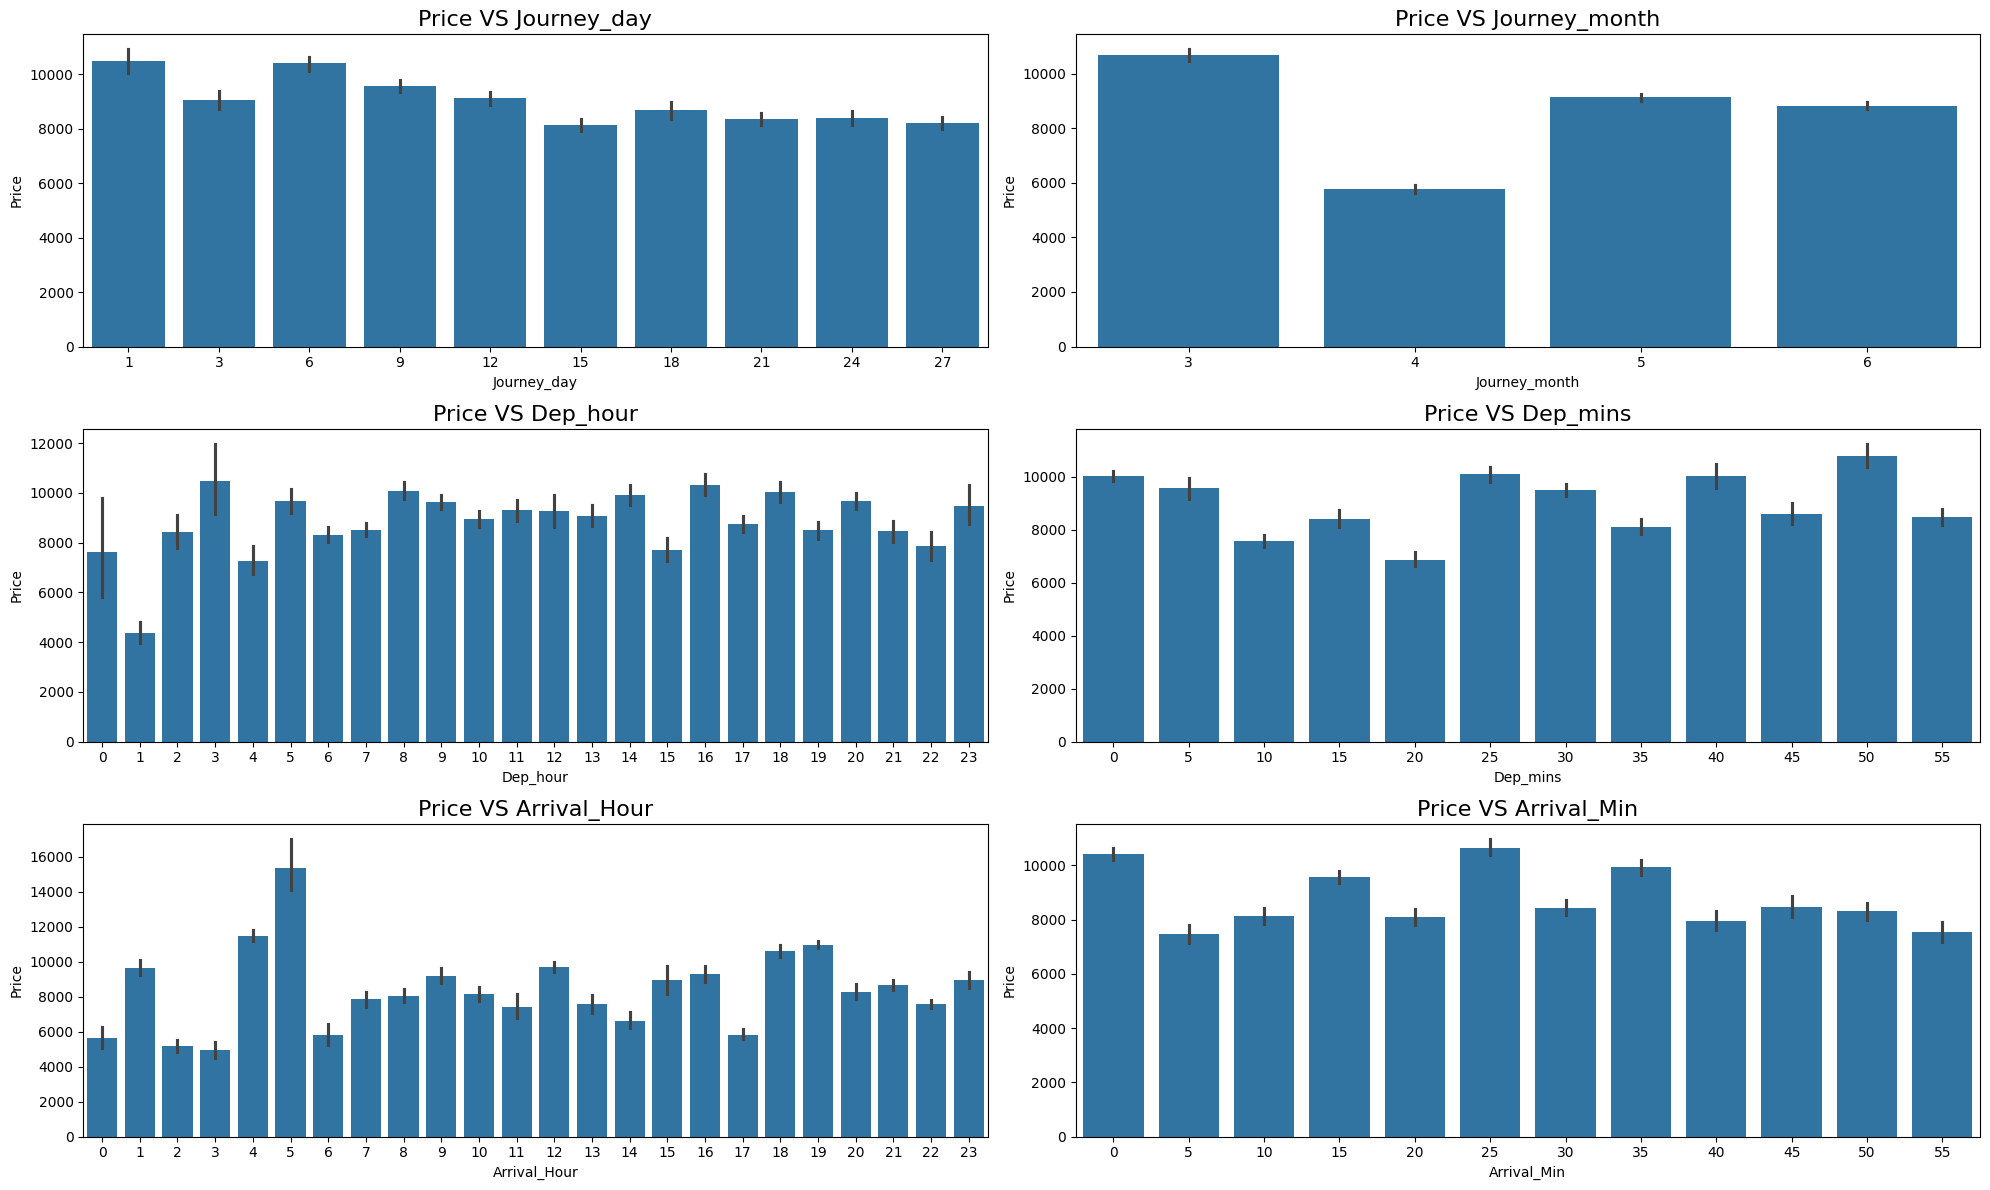

In [27]:
plt.figure(figsize=(20,12))
plot=1
for i in num_cols:
  plt.subplot(3,2,plot)
  sns.barplot(x=i,y='Price',data=df)
  plt.title(f'Price VS {i}',fontsize=16)

  plot+=1
plt.tight_layout()
plt.show()

### Price vs Numerical Columns
- Price vs Journey_Day : Not much of a pattern here. There's a slight bump toward the end of the month — possibly weekends or pre-holiday bookings, but it's not strong enough to read too much into.

- Price vs Journey_Month : March to June is peak season and prices reflect that clearly. January and February are the cheapest months — demand drops off after the holiday season. This is one of the more useful features for the model.

- Price vs Dep_Hour : Early morning flights between 5 and 8 AM are cheaper — most people don't want to wake up that early, so demand is lower. Prices climb through the afternoon and into the evening. Late night flights after 10 PM dip again for the same reason.

- Price vs Arrival_Hour : Convenient arrival times cost more. Flights that get you in at a reasonable hour during the day are priced higher than those landing late at night or very early in the morning.

- Price vs Duration_Mins : Longer flights generally cost more that much is expected. Short flights under 200 minutes cluster at lower prices. As duration increases the scatter widens, meaning pricing becomes less predictable for long-haul routes.

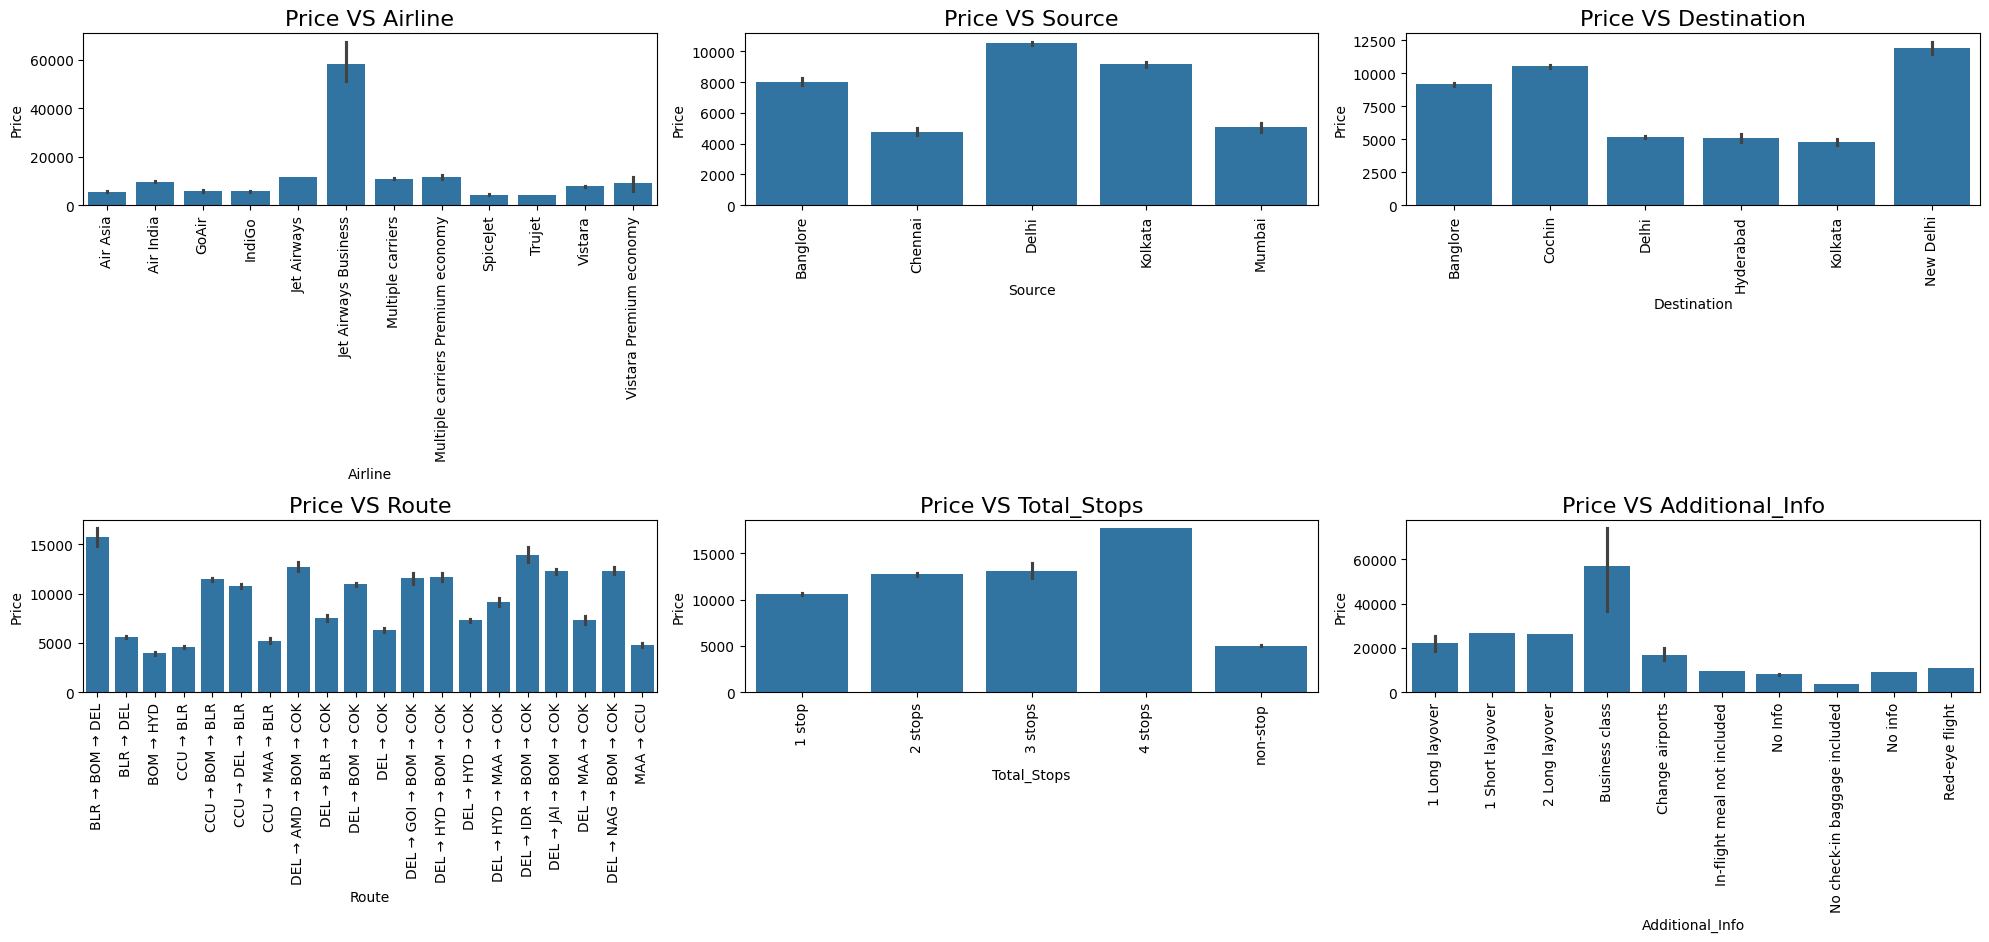

In [28]:
plt.figure(figsize=(20,12))
plot=1
for i in cat_cols:
    plt.subplot(3,3,plot)
    top_categories = df[i].value_counts().index[:20].sort_values(ascending=True)
    sns.barplot(x=i,y='Price',data=df,order=top_categories)
    plt.title(f'Price VS {i}',fontsize=16)
    plt.xticks(rotation=90)
    plot+=1
plt.tight_layout()
plt.show()

### Price Vs Categorical columns
- Price VS Airline : Jet Airways Business is on another level — nearly ₹60,000 average while everyone else is under ₹15,000. Budget airlines like IndiGo, GoAir and SpiceJet sit at the bottom under ₹10,000. The gap between business and economy class airlines is the biggest takeaway here.

- Price VS Source : Delhi is the most expensive city to fly from — highest demand, busiest hub. Chennai and Mumbai are surprisingly cheaper despite being major cities. Where you start your journey does affect the price.

- Price VS Destination : New Delhi is the priciest destination, close to ₹12,000 average. Hyderabad and Kolkata are the cheapest to fly into. One thing worth flagging — Delhi and New Delhi appear separately in the data but they're essentially the same city.

- Price VS Route : BLR to DEL is the most expensive route by a clear margin. Most other routes sit comfortably between ₹5,000 and ₹13,000. Shorter hops like BOM to HYD are naturally the cheapest. Route is informative but has too many unique combinations to use directly in modeling.

- Price VS Total_Stops : Surprisingly, 4 stop flights are the most expensive and non-stop flights are the cheapest. This is because non-stop flights in this dataset are mostly short domestic routes. More stops usually means a longer journey covering more distance — and that pushes the fare up.

- Price VS Additional_Info : Business class entries shoot up to ₹60,000+ with massive variance. Everything else — no info, no meal, no baggage — sits below ₹10,000. Since over 80% of entries are just "No info" and business class is already captured through the Airline column, dropping this feature was the right call.



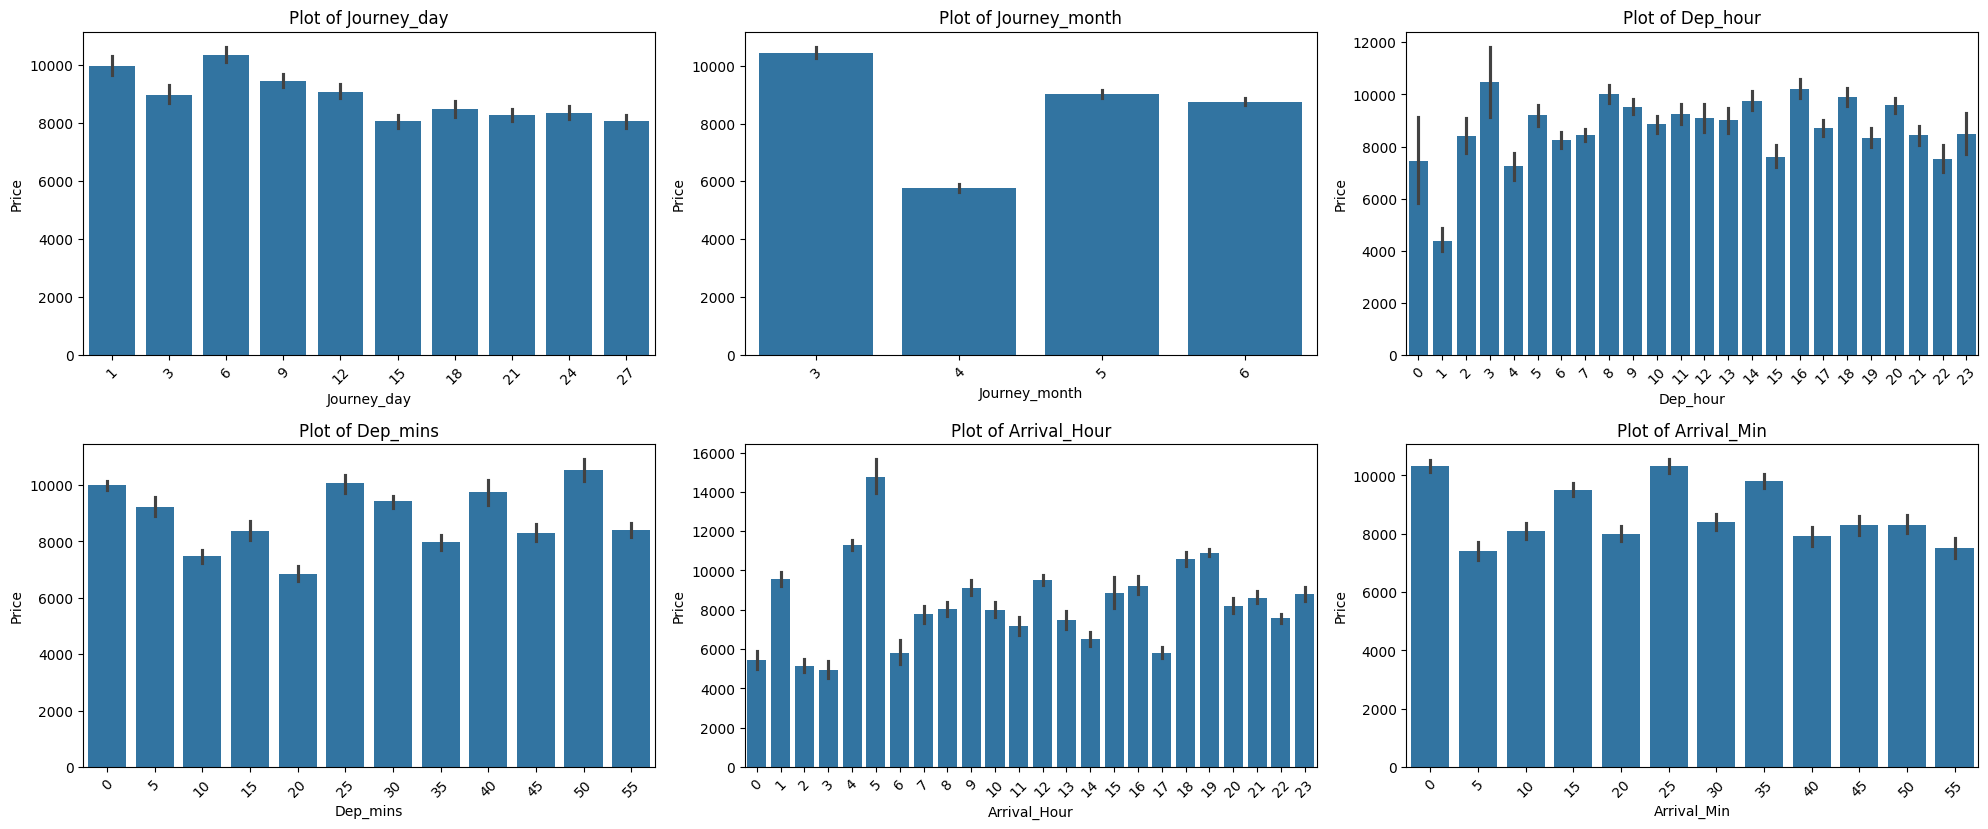

In [84]:
plt.figure(figsize=(20,12))
plot = 1

for i in num_cols:
    plt.subplot(3, 3, plot)
    sns.barplot(x=i, y="Price", data=df)
    plt.title(f"Plot of {i}")
    plt.xticks(rotation=45)
    plot += 1

plt.tight_layout()
plt.show()

### Price vs Numerical Columns
- Price vs Journey_Day : Not much of a pattern here. There's a slight bump toward the end of the month, possibly weekends or pre-holiday bookings but it's not strong enough to read too much into.

- Price vs Journey_Month : March to June is peak season and prices reflect that clearly. January and February are the cheapest months, demand drops off after the holiday season. This is one of the more useful features for the model.

- Price vs Dep_Hour : Early morning flights between 5 and 8 AM are cheaper, most people don't want to wake up that early, so demand is lower. Prices climb through the afternoon and into the evening. Late night flights after 10 PM dip again for the same reason.

- Price vs Arrival_Hour : Convenient arrival times cost more. Flights that get you in at a reasonable hour during the day are priced higher than those landing late at night or very early in the morning.

- Price vs Duration_Mins : Longer flights generally cost more that much is expected. Short flights under 200 minutes cluster at lower prices. As duration increases the scatter widens, meaning pricing becomes less predictable for long-haul routes.

#### 9.1.Multivariate Analysis

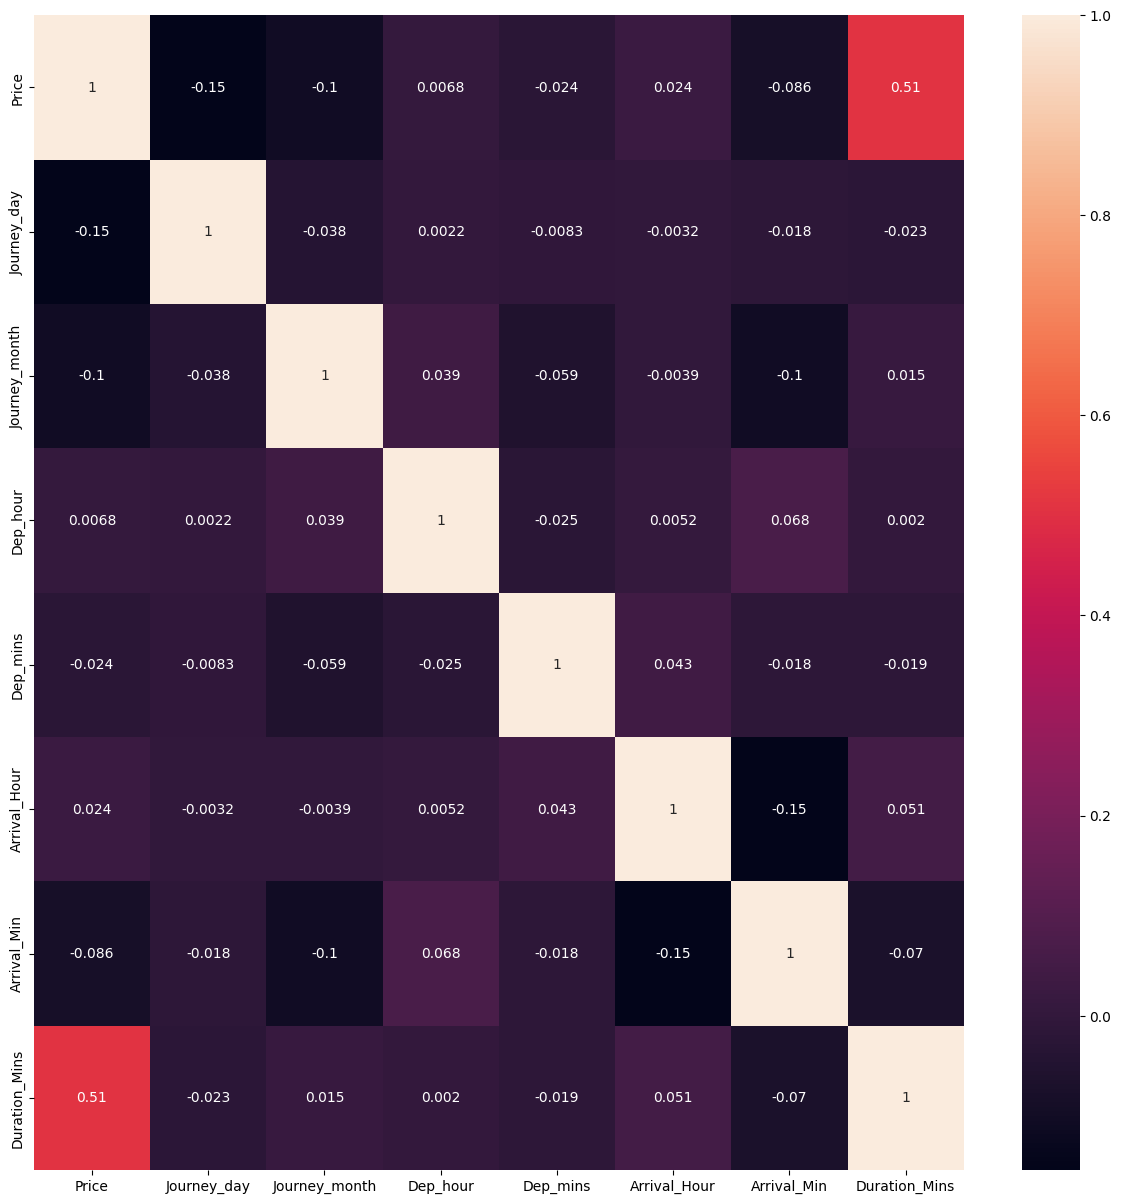

In [30]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True)
plt.show()

### Correlation Heatmap
- Duration is the numerical feature most closely tied to price — longer flights mean higher fares. Journey month has a moderate positive relationship, confirming the seasonal trend we saw earlier. Total stops also shows some positive correlation, though weaker than expected. Departure and arrival hours have a small but noticeable relationship with price.
Journey day, departure minutes, and arrival minutes are essentially flat — they carry almost no useful signal for predicting price. Dropping departure and arrival minutes before modeling would be a reasonable move.
The good news is there's no serious multicollinearity between features, nothing needs to be removed purely for that reason.

## 10. Feature Engineering

#### 10.1 Data PreProcessing


#### 10.1.1  Checking for Duplicate Rows

In [31]:
duplicates = df.duplicated().sum()
duplicates

np.int64(222)

In [32]:
df.drop_duplicates(inplace=True)

In [33]:
df.duplicated().sum()

np.int64(0)

#### 10.1.2 Null value Handling

In [34]:
missing = df.isnull().sum()
missing

,0
Airline,0
Source,0
Destination,0
Route,1
Total_Stops,1
Additional_Info,0
Price,0
Journey_day,0
Journey_month,0
Dep_hour,0


In [35]:
df.dropna(inplace=True)

In [36]:
df.isnull().sum()

,0
Airline,0
Source,0
Destination,0
Route,0
Total_Stops,0
Additional_Info,0
Price,0
Journey_day,0
Journey_month,0
Dep_hour,0


#### 10.1.3 Outlier Handling

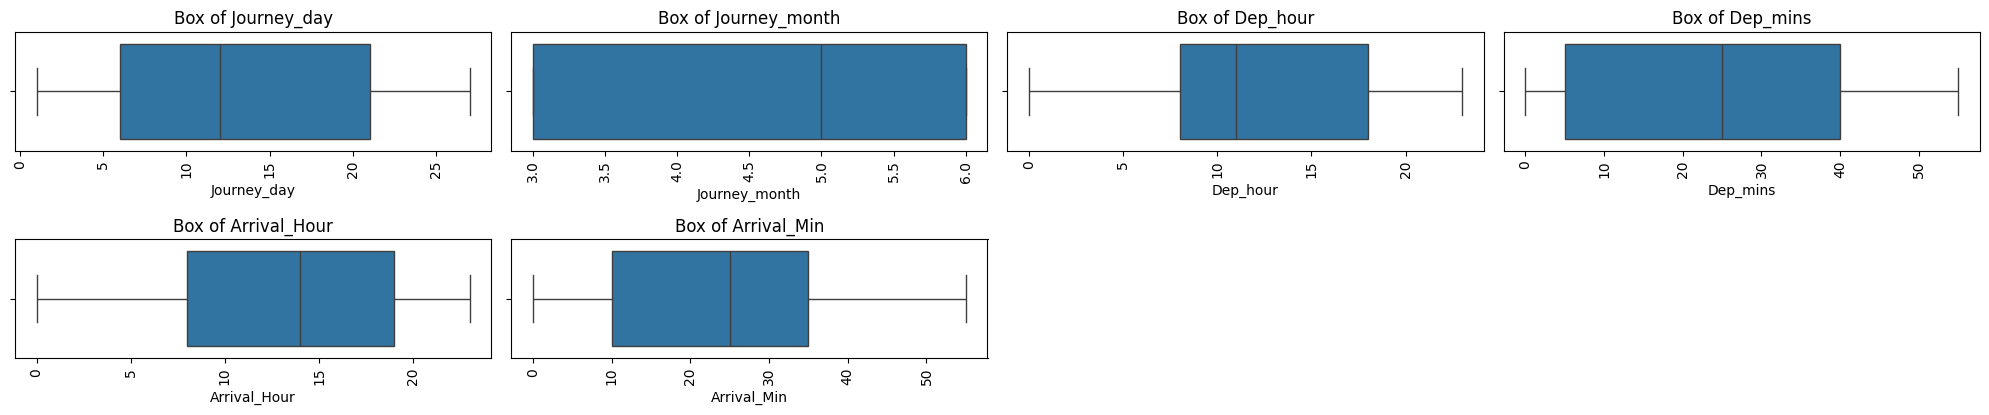

In [37]:
plt.figure(figsize=(20, 10))
plot = 1

for i in num_cols:
        plt.subplot(5, 4, plot)
        sns.boxplot(x=i, data=df)
        plt.title(f"Box of {i}")
        plt.xticks(rotation=90)
        plot += 1

plt.tight_layout()
plt.show()

In [38]:
# IQR Winsorization
def winsorize(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    return df

for col in ['Duration_Mins', 'Price']:
    df = winsorize(df, col)

#### 10.1.4 Encoding

In [39]:
df[cat_cols].head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info


In [40]:
df[cat_cols].nunique()

,0
Airline,12
Source,5
Destination,6
Route,128
Total_Stops,5
Additional_Info,10


In [41]:
# Additional_Info contains almost 80% no_info
# Route and Total_Stops are related to each other
df.drop(["Route", "Additional_Info"], axis = 1, inplace = True)

In [42]:
ordinal_encode_cols = ['Total_Stops']
onehot_encode_cols = ['Source','Destination']

In [43]:
# Ordinal Encoding — Total_Stops (natural order)
stops_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Total_Stops'] = df['Total_Stops'].map(stops_map)

In [44]:
# Target Encoding — Airline (high cardinality, strong price relationship)
global_mean = df['Price'].mean()
airline_mean = df.groupby('Airline')['Price'].mean()
df['Airline_encoded'] = df['Airline'].map(airline_mean)
df['Airline_encoded'].fillna(global_mean, inplace=True)
df.drop('Airline', axis=1, inplace=True)

In [45]:
# One-Hot Encoding — Source, Destination (nominal, low cardinality)
df = pd.get_dummies(df, columns=['Source', 'Destination'], drop_first=True,dtype='int32')
print('Shape after encoding:', df.shape)
df.head()

Shape after encoding: (10460, 19)


,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_mins,Arrival_Hour,Arrival_Min,Duration_Mins,Airline_encoded,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897.0,24,3,22,20,1,10,170,5668.469897,0,0,0,0,0,0,0,0,1
1,2,7662.0,1,5,5,50,13,15,445,9523.584637,0,0,1,0,0,0,0,0,0
2,2,13882.0,9,6,9,25,4,25,1140,11499.535338,0,1,0,0,1,0,0,0,0
3,1,6218.0,12,5,18,5,23,30,325,5668.469897,0,0,1,0,0,0,0,0,0
4,1,13302.0,1,3,16,50,21,35,285,5668.469897,0,0,0,0,0,0,0,0,1


#### 10.2 Feature selection

In [46]:
corr_matrix = df.corr()
price_corr = corr_matrix['Price'].sort_values(ascending=False)
price_corr

,Price
Price,1.000000
Total_Stops,0.644811
Airline_encoded,0.630296
Duration_Mins,0.547944
Destination_Cochin,0.290734
Source_Delhi,0.290734
Destination_New Delhi,0.177621
Arrival_Hour,0.038523
Source_Kolkata,0.025743
Dep_hour,0.005122


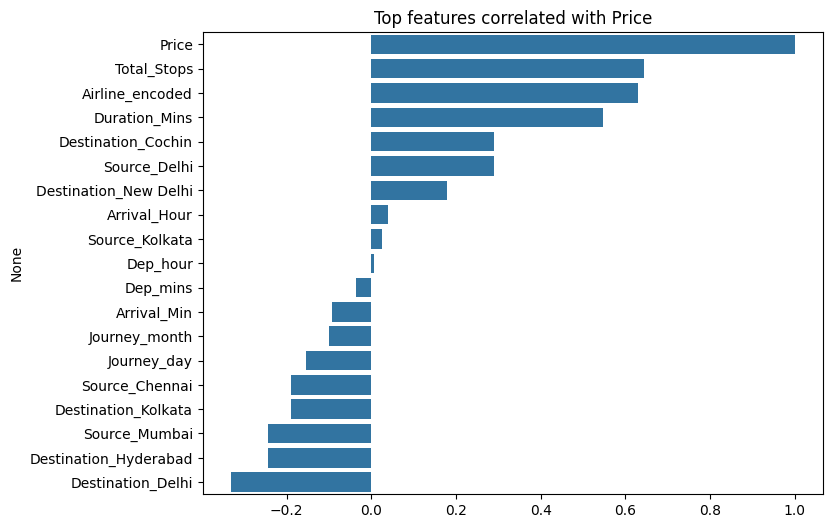

In [47]:
top_corr = price_corr[:]

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top features correlated with Price")
plt.show()

## 11. Modeling

### 11.1 Spliting the Data


In [48]:
# Spliting data in dependent and independent features
x = df.drop("Price",axis=1)
y = df.Price

In [49]:
x.head()

,Total_Stops,Journey_day,Journey_month,Dep_hour,Dep_mins,Arrival_Hour,Arrival_Min,Duration_Mins,Airline_encoded,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,24,3,22,20,1,10,170,5668.469897,0,0,0,0,0,0,0,0,1
1,2,1,5,5,50,13,15,445,9523.584637,0,0,1,0,0,0,0,0,0
2,2,9,6,9,25,4,25,1140,11499.535338,0,1,0,0,1,0,0,0,0
3,1,12,5,18,5,23,30,325,5668.469897,0,0,1,0,0,0,0,0,0
4,1,1,3,16,50,21,35,285,5668.469897,0,0,0,0,0,0,0,0,1


In [50]:
y.head()

,Price
0,3897.0
1,7662.0
2,13882.0
3,6218.0
4,13302.0


### 11.2 Train Test Split

In [51]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [52]:
print('Train size:', x_train.shape)
print('Test size:', x_test.shape)

Train size: (7845, 18)
Test size: (2615, 18)


In [53]:
ss = StandardScaler()
x_train_scaled = ss.fit_transform(x_train)
x_test_scaled = ss.transform(x_test)

### 11.3 Model Building , Validating , Evaluation with and without Hyper Parameter Tuning

In [54]:
# Creating a funnction to run and evaluate the model
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    return {
        "Model": name,
        "Train R2": r2_score(y_train, y_pred_train),
        "Test R2": r2_score(y_test, y_pred_test),
        "MAE": mean_absolute_error(y_test, y_pred_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test))
    }

#### 11.3.1 Linear Regression


In [55]:
lr = LinearRegression()
lr_results = evaluate_model(
    "Linear Regression",
    lr,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

#### 11.3.2 Ridge Regression

In [56]:
ridge = Ridge(alpha=1.0)
ridge_results = evaluate_model(
    "Ridge Regression",
    ridge,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

#### 11.3.3 Lasso Regression

In [57]:
lasso = Lasso(alpha=0.01)
lasso_results = evaluate_model(
    "Lasso Regression",
    lasso,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

#### 11.3.4 Random Forest Regression

In [58]:
rf = RandomForestRegressor()
rf_results = evaluate_model(
    "Random Forest",
    rf,
    x_train,
    x_test,
    y_train,
    y_test
)

#### 11.3.5 GradientBoosting Regression

In [59]:
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gbr_results = evaluate_model(
    "Gradient Boosting",
    gbr,
    x_train,
    x_test,
    y_train,
    y_test
)

#### 11.3.6 XGBoosting Regression

In [60]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

xgb_results = evaluate_model(
    "XGBoost",
    xgb,
    x_train,
    x_test,
    y_train,
    y_test
)

### 11.4 Best Model Based On Train R2, Test R2, MAE, RMSE

In [61]:
results_df = pd.DataFrame([
    lr_results,
    ridge_results,
    lasso_results,
    rf_results,
    gbr_results,
    xgb_results
])

results_df.sort_values(by="Test R2", ascending=False)

,Model,Train R2,Test R2,MAE,RMSE
5,XGBoost,0.855489,0.817963,1313.163347,1817.665016
3,Random Forest,0.954920,0.811678,1174.182461,1848.775542
4,Gradient Boosting,0.797297,0.776012,1472.282077,2016.256595
1,Ridge Regression,0.622035,0.625476,1912.201668,2607.194841
2,Lasso Regression,0.622035,0.625475,1912.225185,2607.198794
0,Linear Regression,0.622035,0.625475,1912.227238,2607.198989


## 12 Hyperparameter Tuning

###  12.1 Random Forest

In [62]:
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1200, num = 12)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(5, 30, num = 6)]
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10, 15, 100]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 5, 10]

In [63]:
# Create the random grid

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf}

In [64]:
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid,scoring='neg_mean_squared_error', n_iter = 50, cv = 5, verbose=2, random_state=42, n_jobs = 1)

In [65]:
rf_random.fit(x_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=10, min_samples_split=100, n_estimators=400; total time=   0.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=10, min_samples_split=100, n_estimators=400; total time=   0.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=10, min_samples_split=100, n_estimators=400; total time=   0.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=10, min_samples_split=100, n_estimators=400; total time=   0.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=10, min_samples_split=100, n_estimators=400; total time=   0.9s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_est

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=50, n_jobs=1,
                   param_distributions={'max_depth': [5, 10, 15, 20, 25, 30],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 10, 15,
                                                              100],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800,
                                                         900, 1000, 1100,
                                                         1200]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [66]:
rf_random.best_params_

{'n_estimators': 1000,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 15}

In [67]:
rf1 = RandomForestRegressor(n_estimators = 1000, min_samples_split= 2, min_samples_leaf= 1, max_features= 'sqrt', max_depth= 25)
rf1_results = evaluate_model(
    " Tuned Random Forest ",
    rf1,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

In [68]:
rf1_results

{'Model': ' Tuned Random Forest ',
 'Train R2': 0.9540881963103542,
 'Test R2': 0.8023694855923127,
 'MAE': 1248.1379561617414,
 'RMSE': np.float64(1893.9167702515867)}

### 12.2 XGBoost

In [69]:
n_estimators = [int(x) for x in np.linspace(start=100, stop=1200, num=12)]
# Learning rate — controls how much each tree contributes
learning_rate = [0.01, 0.05, 0.1, 0.2, 0.3]
# Maximum depth of each tree
max_depth = [int(x) for x in np.linspace(3, 15, num=6)]
# Minimum sum of instance weight needed in a child
min_child_weight = [1, 3, 5, 7, 10]
# Fraction of samples used per tree
subsample = [0.6, 0.7, 0.8, 0.9, 1.0]
# Fraction of features used per tree
colsample_bytree = [0.6, 0.7, 0.8, 0.9, 1.0]
# L1 regularization
reg_alpha = [0, 0.01, 0.1, 0.5, 1]
# L2 regularization
reg_lambda = [0.5, 1, 1.5, 2, 5]

In [70]:
random_grid = {'n_estimators': n_estimators,
               'learning_rate':learning_rate,
               'max_depth': max_depth,
               'min_child_weight': min_child_weight,
               'subsample': subsample,
               'colsample_bytree': colsample_bytree,
               'reg_alpha':reg_alpha,
               'reg_lambda': reg_lambda}

In [71]:
xgb_random = RandomizedSearchCV(estimator = xgb, param_distributions = random_grid,scoring='neg_mean_squared_error', n_iter = 20, cv = 5, verbose=2, random_state=42, n_jobs = 1)

In [72]:
xgb_random.fit(x_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=12, min_child_weight=3, n_estimators=400, reg_alpha=0.5, reg_lambda=1, subsample=0.9; total time=   0.8s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=12, min_child_weight=3, n_estimators=400, reg_alpha=0.5, reg_lambda=1, subsample=0.9; total time=   0.9s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=12, min_child_weight=3, n_estimators=400, reg_alpha=0.5, reg_lambda=1, subsample=0.9; total time=   0.9s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=12, min_child_weight=3, n_estimators=400, reg_alpha=0.5, reg_lambda=1, subsample=0.9; total time=   0.9s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=12, min_child_weight=3, n_estimators=400, reg_alpha=0.5, reg_lambda=1, subsample=0.9; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.3, max_depth=15, min_child_weight=5, n_estimators=600, reg_alpha=0

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=0.8, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2,
                                                          0.3],
                                        'max_depth': [3, 5, 7, 10, 12, 15],
                                        'min_child_weight': [1, 3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800,
                                                         900, 1000, 1100,
                                                         1200],
                                        'reg_alpha': [0, 0.01, 0.1, 0.5, 1],
                                        'reg_lambda': [0.5, 1, 1.5, 2, 5],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [73]:
xgb_random.best_params_

{'subsample': 0.8,
 'reg_lambda': 2,
 'reg_alpha': 0.01,
 'n_estimators': 600,
 'min_child_weight': 1,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 0.7}

In [74]:
xgb2 = XGBRegressor(subsample= 0.6,
 reg_lambda= 2,
 reg_alpha= 0,
 n_estimators=800,
 min_child_weight= 3,
 max_depth= 5,
 learning_rate= 0.1,
 colsample_bytree= 1.0)
xgb2_results = evaluate_model(
    "Tuned XGBoost",
    xgb2,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

In [75]:
xgb2_results

{'Model': 'Tuned XGBoost',
 'Train R2': 0.9338410978070409,
 'Test R2': 0.830569888475835,
 'MAE': 1172.353044849053,
 'RMSE': np.float64(1753.5945516796858)}

In [76]:
results_df = pd.DataFrame([
    lr_results,
    ridge_results,
    lasso_results,
    rf_results,
    rf1_results,
    gbr_results,
    xgb_results,
    xgb2_results
])

results_df.sort_values(by="Test R2", ascending=False)

,Model,Train R2,Test R2,MAE,RMSE
7,Tuned XGBoost,0.933841,0.830570,1172.353045,1753.594552
6,XGBoost,0.855489,0.817963,1313.163347,1817.665016
3,Random Forest,0.954920,0.811678,1174.182461,1848.775542
4,Tuned Random Forest,0.954088,0.802369,1248.137956,1893.916770
5,Gradient Boosting,0.797297,0.776012,1472.282077,2016.256595
1,Ridge Regression,0.622035,0.625476,1912.201668,2607.194841
2,Lasso Regression,0.622035,0.625475,1912.225185,2607.198794
0,Linear Regression,0.622035,0.625475,1912.227238,2607.198989


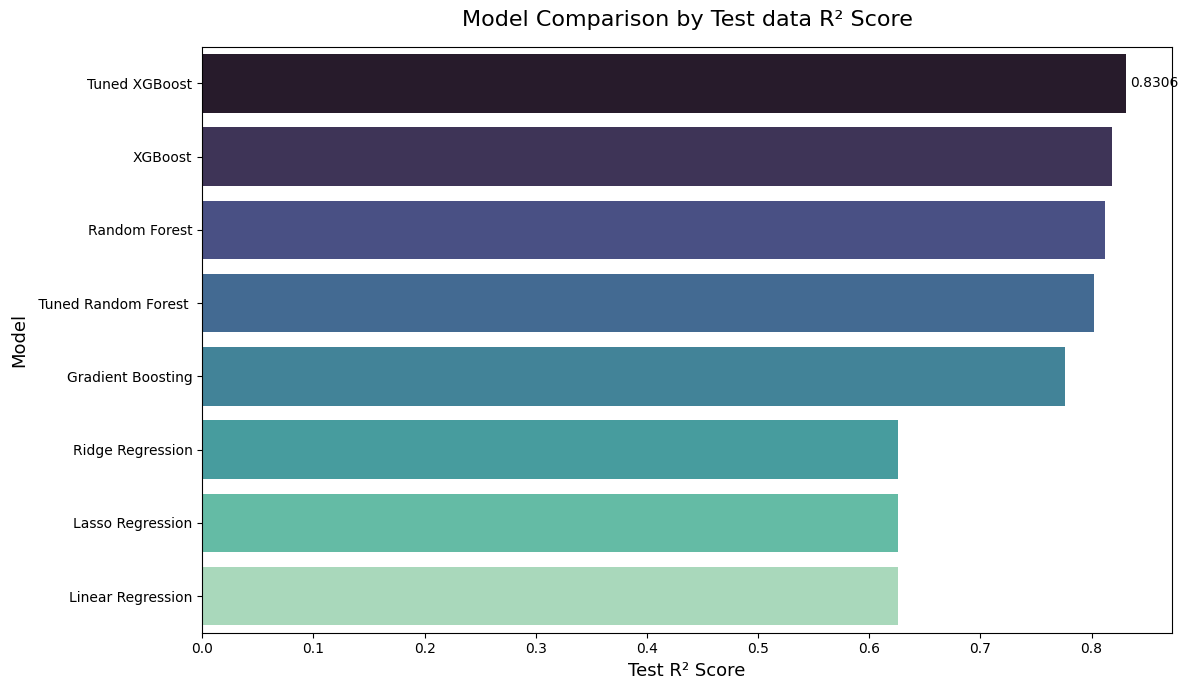

In [77]:
sorted_df = results_df.sort_values(by='Test R2', ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=sorted_df,
    y='Model',
    x='Test R2',
    palette='mako'
)
ax.set_title('Model Comparison by Test data R² Score', fontsize=16, pad=15)
ax.set_xlabel('Test R² Score', fontsize=13)
ax.set_ylabel('Model', fontsize=13)
ax.bar_label(ax.containers[0], fmt='%.4f', padding=3)
plt.tight_layout()
plt.show()

In [78]:
best_row = results_df.loc[results_df['Test R2'].idxmax()]
best_model_name = best_row['Model']
best_model_metrics = best_row[['Train R2' , 'Test R2', 'MAE', 'RMSE']]
print("="*45)
print(f"\nBest Model: {best_model_name}")
print("="*45)
print(best_model_metrics.to_string())


Best Model: Tuned XGBoost
Train R2       0.933841
Test R2         0.83057
MAE         1172.353045
RMSE        1753.594552


In [79]:
with open("model.pkl","wb") as f:
    pickle.dump(xgb2,f)

In [81]:
# Load a preprocessor object from a pickled file
with open("model.pkl","rb") as f:
    preprocessor=pickle.load(f)